# Multi-dataset: Motif Enrichment Analysis

This example demonstrates how to discover enriched spatial motifs across **multiple fields
of view (FOVs)** and compare motif patterns between conditions using `spatial_query_multi`.

When you have multiple tissue sections or experimental conditions, `spatial_query_multi`
pools information across FOVs to provide condition-level motif enrichment results. You can
also run enrichment per condition to compare spatial organization patterns.

**Dataset:** CODEX spatial proteomics from colorectal cancer — CLR (Crohn's-Like Reaction)
vs DII (Diffuse Inflammatory Infiltration) immune subtypes
**Key API:** `spatial_query_multi.motif_enrichment_dist` and `spatial_query_multi.motif_enrichment_knn`

## Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import anndata as ad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from SpatialQuery import spatial_query_multi

## Load Data & Initialize

In [3]:
DATA_DIR = "../data/codex_cancer"

adata = ad.read_h5ad(f"{DATA_DIR}/codex_data.h5ad")

# Assign immune subtype labels
adata.obs["state"] = "CLR"
adata.obs["state"][adata.obs["groups"] == 2] = "DII"

print(f'Max value: {adata.X.max()}')
adata

Max value: 54776.6953125


AnnData object with n_obs × n_vars = 258385 × 56
    obs: 'CellID', 'ClusterID', 'EventID', 'File Name', 'Region', 'TMA_AB', 'TMA_12', 'Index in File', 'groups', 'patients', 'spots', 'cell_id', 'size:size', 'HOECHST1_Cyc_1_ch_1', 'DRAQ5_Cyc_23_ch_4', 'Profile_Homogeneity:Fiter1', 'ClusterSize', 'ClusterName', 'neighborhood10', 'CD4+ICOS+', 'CD4+Ki67+', 'CD4+PD-1+', 'CD68+CD163+ICOS+', 'CD68+CD163+Ki67+', 'CD68+CD163+PD-1+', 'CD68+ICOS+', 'CD68+Ki67+', 'CD68+PD-1+', 'CD8+ICOS+', 'CD8+Ki67+', 'CD8+PD-1+', 'Treg-ICOS+', 'Treg-Ki67+', 'Treg-PD-1+', 'neighborhood number final', 'neighborhood name', 'state'
    var: 'marker_name', 'full_name', 'cell_type_annotation', 'cycle', 'channel'
    uns: 'data_source', 'groups_mapping', 'n_markers', 'technology'
    obsm: 'X_spatial_global', 'X_spatial_tile'

Inspect `adata.obsm` for spatial coordinates, `adata.obs` for cell type labels and FOV identifiers, and `adata.var` for feature names. Then set the corresponding column names below. This data need to be normalized. For the spatial proteomics data, we perform feature-wise z-score normalization.

In [4]:
# Feature-wise z-score normalization for protein expression
adata.X = (adata.X - adata.X.mean(axis=0)) / adata.X.std(axis=0)

In [5]:
spatial_key = "X_spatial_tile"
label_key = "ClusterName"
feature_name = "marker_name"
fov_key = "File Name"

In [6]:
# Split data by FOV and immune subtype
clr_data = adata[adata.obs["state"] == "CLR"]
dii_data = adata[adata.obs["state"] == "DII"]

clr_datas = [clr_data[clr_data.obs[fov_key] == f] for f in clr_data.obs[fov_key].unique()]
dii_datas = [dii_data[dii_data.obs[fov_key] == f] for f in dii_data.obs[fov_key].unique()]

ds_names = ["CLR"] * len(clr_datas) + ["DII"] * len(dii_datas)
adata_fovs = clr_datas + dii_datas

print(f"CLR FOVs: {len(clr_datas)}, DII FOVs: {len(dii_datas)}")

CLR FOVs: 68, DII FOVs: 72


In [7]:
spm = spatial_query_multi(
    adatas=adata_fovs,
    datasets=ds_names,
    spatial_key=spatial_key,
    label_key=label_key,
    feature_name=feature_name,
    build_gene_index=False,
    if_lognorm=False,  # data is already z-score normalized
    if_normalize_spatial_coord=True,
)


Auto-normalizing spatial coordinates: mean nearest neighbor distance = 1.0
Scale factor: 0.0448
build_gene_index is False. Using adata.X for gene expression analysis.

Auto-normalizing spatial coordinates: mean nearest neighbor distance = 1.0
Scale factor: 0.0311
build_gene_index is False. Using adata.X for gene expression analysis.

Auto-normalizing spatial coordinates: mean nearest neighbor distance = 1.0
... (548 lines omitted) ...
Scale factor: 0.0421
build_gene_index is False. Using adata.X for gene expression analysis.


## Cell Type Composition

Before motif analysis, inspect the cell type composition across conditions to ensure
sufficient representation of the anchor cell type.

/var/folders/wl/y90xsxr94l78931lqz6nyvz80000gp/T/ipykernel_52641/2336141135.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(name)
/var/folders/wl/y90xsxr94l78931lqz6nyvz80000gp/T/ipykernel_52641/2336141135.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(name)
/Users/sa3520/BWH/spatial query/python/SpatialQuery/spatial_query_multiple_fov.py:1441: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(colorma

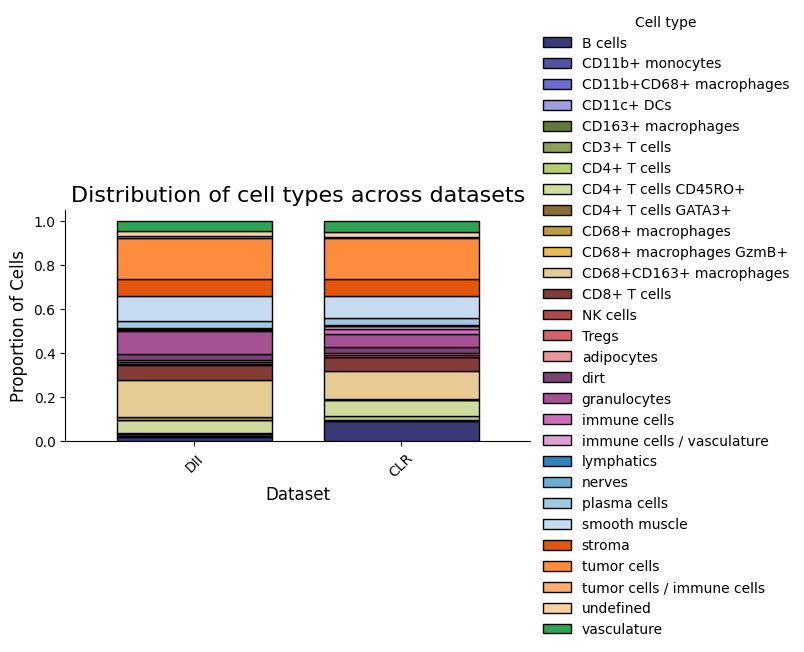

In [8]:
from matplotlib.colors import ListedColormap
import matplotlib.cm as cm

# More than 20 cell types, need to customize colors to avoid repeats in tab20. Otherwise, just call spm.plot_cell_type_distribution()
# Combine tab20b + tab20c for 40 unique colors (needed when >20 cell types)
all_colors = []
for name in ["tab20b", "tab20c"]:
    cmap = cm.get_cmap(name)
    all_colors.extend([cmap(i) for i in range(cmap.N)])

seen = set()
unique_colors = []
for c in all_colors:
    key = tuple(round(v, 4) for v in c)
    if key not in seen:
        seen.add(key)
        unique_colors.append(c)

custom_cmap = ListedColormap(unique_colors, name="tab40")

spm.plot_cell_type_distribution(colormap=custom_cmap)

## Distance-based Motif Enrichment Per Condition

`motif_enrichment_dist` discovers enriched spatial motifs using radius-based neighborhoods.
If no motifs are specified, it first mines frequent cell type patterns around the anchor
cell type, then tests each pattern for statistical enrichment using a hypergeometric test.

Run it separately for each condition by passing the `dataset` parameter. This pools all
FOVs within that condition and reports enriched motifs.

**Key parameters:**

| Parameter | Description |
|-----------|-------------|
| `ct` | Anchor cell type to analyze neighborhoods around |
| `motifs` | Specific motif(s) to test. If `None`, automatically discovers frequent patterns |
| `dataset` | Condition name(s) to restrict the analysis to. If `None`, uses all datasets |
| `max_dist` | Maximum distance (radius) for considering a cell as a neighbor |
| `min_size` | Minimum neighborhood size for each anchor cell to be included |
| `min_support` | Minimum frequency threshold for a pattern to be considered frequent (0–1) |
| `return_cellID` | If `True`, also return cell IDs of motif+ anchors and their neighbors |

**Key output columns:**

| Column | Description |
|--------|-------------|
| `center` | Anchor cell type |
| `motifs` | List of cell types in the motif |
| `n_center_motif` | Number of anchor cells with the motif in their neighborhood |
| `n_center` | Total number of anchor cells |
| `n_motif` | Total number of cells belonging to the motif cell types |
| `expectation` | Expected count under the hypergeometric null |
| `p-values` | P-value from hypergeometric test |
| `adj-pval` | FDR-corrected p-value (when multiple motifs tested) |
| `if_significant` | Whether the enrichment is statistically significant |

In [9]:
anchor_ct = "B cells"
max_dist = 5
min_support = 0.5
clr = "CLR"
dii = "DII"

enrich_per_condition = {}
for ds in [clr, dii]:
    result = spm.motif_enrichment_dist(
        ct=anchor_ct,
        dataset=ds,
        max_dist=max_dist,
        min_support=min_support,
    )
    enrich_per_condition[ds] = result[result["if_significant"]]
    print(f"{ds}: {len(enrich_per_condition[ds])} enriched motifs")

CLR: 2 enriched motifs
DII: 14 enriched motifs


In [10]:
# Combine results for side-by-side comparison
enrich_all = pd.DataFrame()
for ds, df in enrich_per_condition.items():
    df = df.copy()
    df["dataset"] = ds
    enrich_all = pd.concat([enrich_all, df], axis=0)

enrich_all.reset_index(drop=True, inplace=True)
enrich_all

,center,motifs,n_center_motif,n_center,n_motif,expectation,p-values,adj-pval,if_significant,dataset
0,B cells,"[B cells, CD4+ T cells CD45RO+, CD8+ T cells]",6680,10269,27291,2523.399564,0.000000e+00,0.000000e+00,True,CLR
1,B cells,"[B cells, tumor cells]",5382,10269,24255,2242.682805,0.000000e+00,0.000000e+00,True,CLR
2,B cells,"[B cells, CD8+ T cells]",1704,2774,26742,503.531726,0.000000e+00,0.000000e+00,True,DII
3,B cells,"[B cells, CD4+ T cells CD45RO+]",1647,2774,24170,455.102902,0.000000e+00,0.000000e+00,True,DII
4,B cells,"[B cells, stroma]",1592,2774,26083,491.123252,0.000000e+00,0.000000e+00,True,DII
5,B cells,"[B cells, CD68+CD163+ macrophages]",1495,2774,30610,576.363254,0.000000e+00,0.000000e+00,True,DII
6,B cells,"[B cells, smooth muscle]",1425,2774,19963,375.888260,0.000000e+00,0.000000e+00,True,DII
7,B cells,"[CD4+ T cells CD45RO+, CD8+ T cells]",1668,2774,58370,1099.063153,1.527325e-107,3.818311e-107,True,DII
8,B cells,"[CD8+ T cells, smooth muscle]",1393,2774,47767,899.416646,1.183362e-85,2.535775e-85,True,DII
9,B cells,"[CD4+ T cells CD45RO+, stroma]",1566,2774,57711,1086.654679,3.314561e-77,6.214802e-77,True,DII


## Visualize Motif Enrichment Heatmap

Build a heatmap comparing enriched motifs across conditions. Each column is a motif
(labeled by condition), each row is a cell type, and the color shows the frequency
(fraction of anchor cells containing that motif).

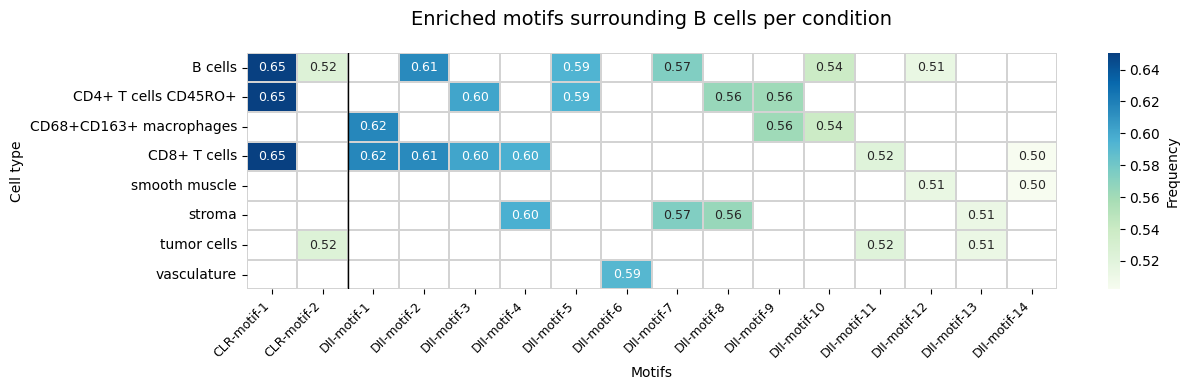

In [11]:
enrich = enrich_all.copy()
enrich["frequency"] = enrich["n_center_motif"] / enrich["n_center"]

# Sort and label motifs
enrich = enrich.sort_values(by=["dataset", "frequency"], ascending=[True, False]).reset_index(drop=True)
enrich["motif_num"] = enrich.groupby("dataset").cumcount() + 1
enrich["motif_group"] = enrich["dataset"] + "_motif_" + enrich["motif_num"].astype(str)

# Build heatmap
enrich_expanded = enrich.explode("motifs")
heatmap_data = enrich_expanded.pivot_table(
    index="motifs", columns="motif_group", values="frequency", aggfunc="first",
)
col_order = enrich["motif_group"].tolist()
heatmap_data = heatmap_data[col_order]
heatmap_data.columns = [c.replace("_", "-") for c in heatmap_data.columns]

# Reorder by condition
col_reordered = []
for ds in [clr, dii]:
    col_reordered.extend([c for c in heatmap_data.columns if c.startswith(ds)])
heatmap_data = heatmap_data[col_reordered]

# Find condition boundaries
boundaries = []
prev = None
for i, c in enumerate(col_reordered):
    cur = c.split("-motif")[0]
    if prev and cur != prev:
        boundaries.append(i)
    prev = cur

fig, ax = plt.subplots(figsize=(max(8, len(col_reordered) * 0.8), max(4, len(heatmap_data) * 0.45)))
sns.heatmap(
    heatmap_data, cmap="GnBu", linewidths=0.1, linecolor="lightgrey",
    annot=True, fmt=".2f", annot_kws={"fontsize": 9},
    cbar_kws={"label": "Frequency"}, ax=ax,
)
for b in boundaries:
    ax.axvline(x=b, color="black", linewidth=1)

plt.title(f"Enriched motifs surrounding {anchor_ct} per condition", fontsize=14, pad=20)
plt.ylabel("Cell type")
plt.xlabel("Motifs")
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.tight_layout()
plt.show()

## KNN-based Motif Enrichment

`motif_enrichment_knn` defines neighborhoods by the *k* nearest neighbors rather than a
fixed radius. This is useful when cell density varies across FOVs. The statistical test
and output format are the same as the distance-based version.

**Key parameters:**

| Parameter | Description |
|-----------|-------------|
| `ct` | Anchor cell type to analyze neighborhoods around |
| `motifs` | Specific motif(s) to test. If `None`, automatically discovers frequent patterns |
| `dataset` | Condition name(s) to restrict the analysis to. If `None`, uses all datasets |
| `k` | Number of nearest neighbors to define the neighborhood |
| `min_support` | Minimum frequency threshold for a pattern to be considered frequent (0–1) |
| `max_dist` | Maximum distance cutoff for neighbors (filters out distant KNN) |
| `return_cellID` | If `True`, also return cell IDs of motif+ anchors and their neighbors |

In [12]:
k = 50

enrich_knn_per_condition = {}
for ds in [clr, dii]:
    result = spm.motif_enrichment_knn(
        ct=anchor_ct,
        dataset=ds,
        k=k,
        min_support=min_support,
    )
    enrich_knn_per_condition[ds] = result[result["if_significant"]]
    print(f"{ds} (KNN): {len(enrich_knn_per_condition[ds])} enriched motifs")

CLR (KNN): 4 enriched motifs
DII (KNN): 20 enriched motifs


In [13]:
enrich_knn_per_condition[clr]

,center,motifs,n_center_motif,n_center,n_motif,expectation,p-values,adj-pval,if_significant
0,B cells,"[B cells, CD4+ T cells CD45RO+, CD8+ T cells]",7346,10269,38089,3521.811806,0.0,0.0,True
1,B cells,"[B cells, CD4+ T cells CD45RO+, tumor cells]",5583,10269,31014,2867.638199,0.0,0.0,True
2,B cells,"[B cells, CD68+CD163+ macrophages]",5533,10269,38564,3565.731589,0.0,0.0,True
3,B cells,"[B cells, stroma]",5405,10269,35723,3303.045056,0.0,0.0,True


In [14]:
enrich_knn_per_condition[dii]

,center,motifs,n_center_motif,n_center,n_motif,expectation,p-values,adj-pval,if_significant
0,B cells,"[B cells, CD8+ T cells, smooth muscle]",1442,2774,28123,529.534916,0.000000e+00,0.000000e+00,True
1,B cells,"[B cells, CD4+ T cells CD45RO+, smooth muscle]",1401,2774,26189,493.119152,0.000000e+00,0.000000e+00,True
2,B cells,"[B cells, CD4+ T cells CD45RO+, tumor cells]",1481,2774,30756,579.112324,0.000000e+00,0.000000e+00,True
3,B cells,"[B cells, CD8+ T cells, tumor cells]",1534,2774,33064,622.570226,2.539186e-314,1.777430e-313,True
4,B cells,"[B cells, CD8+ T cells, vasculature]",1435,2774,30545,575.139353,3.203226e-291,1.793807e-290,True
5,B cells,"[B cells, CD4+ T cells CD45RO+, CD8+ T cells, ...",1450,2774,31278,588.941191,4.633437e-289,2.162271e-288,True
6,B cells,"[B cells, stroma, tumor cells]",1439,2774,33015,621.647593,2.032194e-256,8.128774e-256,True
7,B cells,"[B cells, CD4+ T cells CD45RO+, CD68+CD163+ ma...",1397,2774,34549,650.531658,2.785379e-212,9.748827e-212,True
8,B cells,"[B cells, CD68+CD163+ macrophages, stroma]",1471,2774,40034,753.810078,9.819875e-186,3.055072e-185,True
9,B cells,"[CD4+ T cells CD45RO+, CD8+ T cells, vasculature]",1496,2774,56576,1065.283484,4.428276e-63,1.239917e-62,True


## Targeted Motif Enrichment

Test a specific motif hypothesis across conditions. Here we test a TLS-associated motif.

In [15]:
motif_tls = ["B cells", "CD4+ T cells", "CD4+ T cells CD45RO+", "CD8+ T cells"]

result_clr = spm.motif_enrichment_dist(
    ct=anchor_ct,
    motifs=motif_tls,
    dataset=clr,
    max_dist=max_dist,
)
result_clr

,center,motifs,n_center_motif,n_center,n_motif,expectation,p-values,if_significant
0,B cells,"[B cells, CD4+ T cells, CD4+ T cells CD45RO+, ...",3225,10269,11385,1052.687847,0.0,True


In [16]:
motif_tls = ["B cells", "CD4+ T cells", "CD4+ T cells CD45RO+", "CD8+ T cells"]

result_dii = spm.motif_enrichment_dist(
    ct=anchor_ct,
    motifs=motif_tls,
    dataset=dii,
    max_dist=max_dist,
)
result_dii

,center,motifs,n_center_motif,n_center,n_motif,expectation,p-values,if_significant
0,B cells,"[B cells, CD4+ T cells, CD4+ T cells CD45RO+, ...",249,2774,3063,57.673984,1.012861e-83,True
